In [30]:
from pathlib import Path
from functools import namedtuple

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper")
import tqdm.auto as tqdm

from dti import data
from dti.utils import scaffold_split
from dti.constants import ACT, ASSAY

In [2]:
data_path = Path("..") / "data" / "raw"
Row = namedtuple("Row", ["overlap", "correlation"])

# Assay overlap in scaffold splits

In [3]:
def sample_assay_overlap(
    df: pd.DataFrame, seed: int, fillna: bool = False, progress: bool = False
):
    df_train, df_test = scaffold_split(df, seed=seed, progress=progress)
    overlap = df_test[ASSAY].isin(df_train[ASSAY]).mean()
    predictor = df_train.groupby(ASSAY)[[ACT]].agg("mean")
    df_test = df_test.join(
        predictor.rename(columns={ACT: "assay_mean"}), on=ASSAY, how="left"
    )
    if fillna:
        df_test.fillna(value=df_train[ACT].mean(), inplace=True)
    corr = df_test.corr(numeric_only=True).loc["assay_mean", "activity_value"]

    return overlap, corr

## ChEMBL

sample overlap:   0%|          | 0/100 [00:00<?, ?it/s]

scaffold:   0%|          | 0/179982 [00:00<?, ?it/s]

overlap        0.895172
correlation    0.695651
dtype: float64

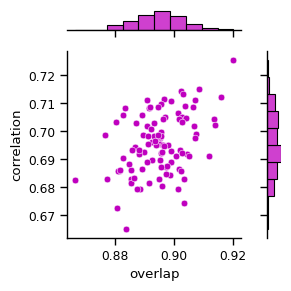

In [25]:
df = data.load_kinodata(data_path / "activities-chembl33_v0.5.csv")
dcorr = pd.DataFrame(
    [
        Row(*sample_assay_overlap(df, seed, fillna=True, progress=seed == 0))
        for seed in tqdm.tqdm(range(100), desc="sample overlap")
    ]
)
sns.jointplot(
    dcorr,
    x="overlap",
    y="correlation",
    kind="scatter",
    color="m",
    marginal_ticks=False,
    marginal_kws=dict(bins=10),
    height=3,
)
plt.tight_layout()
plt.savefig("img/kinodata_scaffold_assay_overlap.pdf")
dcorr.mean()

  0%|          | 0/100 [00:00<?, ?it/s]

scaffold:   0%|          | 0/838155 [00:00<?, ?it/s]

overlap        0.932732
correlation    0.734970
dtype: float64

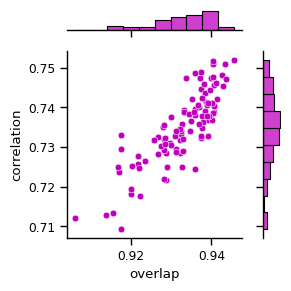

In [23]:
df = data.load_landrum(data_path / "omnivore.csv")
dcorr = pd.DataFrame(
    [
        Row(*sample_assay_overlap(df, seed, fillna=True, progress=seed == 0))
        for seed in tqdm.tqdm(range(100))
    ]
)
sns.jointplot(
    dcorr,
    x="overlap",
    y="correlation",
    kind="scatter",
    color="m",
    marginal_ticks=False,
    marginal_kws=dict(bins=10),
    height=3,
)
plt.tight_layout()
plt.savefig("img/omnivore_scaffold_assay_overlap.pdf")
dcorr.mean()

  0%|          | 0/100 [00:00<?, ?it/s]

scaffold:   0%|          | 0/259823 [00:00<?, ?it/s]

overlap        0.972448
correlation    0.730687
dtype: float64

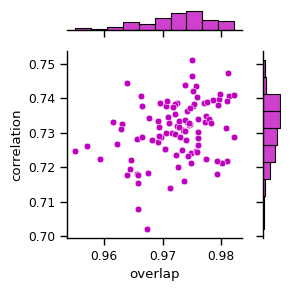

In [24]:
df = data.load_landrum(data_path / "landrum.csv")
dcorr = pd.DataFrame(
    [
        Row(*sample_assay_overlap(df, seed, fillna=True, progress=seed == 0))
        for seed in tqdm.tqdm(range(100))
    ]
)
sns.jointplot(
    dcorr,
    x="overlap",
    y="correlation",
    kind="scatter",
    color="m",
    marginal_ticks=False,
    marginal_kws=dict(bins=10),
    height=3,
)
plt.tight_layout()
plt.savefig("img/landrum_scaffold_assay_overlap.pdf")
dcorr.mean()

## NCI Cancer

  0%|          | 0/100 [00:00<?, ?it/s]

scaffold:   0%|          | 0/49741 [00:00<?, ?it/s]

overlap        0.975501
correlation    0.331288
dtype: float64

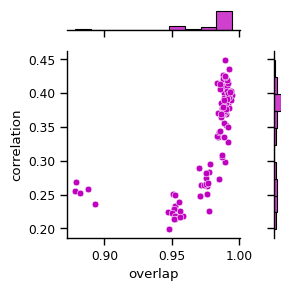

In [28]:
df = data.load_nci(data_path / "atcc.csv.bkp")
dcorr = pd.DataFrame(
    [
        Row(*sample_assay_overlap(df, seed, fillna=True, progress=seed == 0))
        for seed in tqdm.tqdm(range(100))
    ]
)
sns.jointplot(
    dcorr,
    x="overlap",
    y="correlation",
    kind="scatter",
    color="m",
    marginal_ticks=False,
    marginal_kws=dict(bins=10),
    height=3,
)
plt.tight_layout()
dcorr.mean()

  0%|          | 0/100 [00:00<?, ?it/s]

scaffold:   0%|          | 0/48186 [00:00<?, ?it/s]

overlap        0.975251
correlation    0.326010
dtype: float64

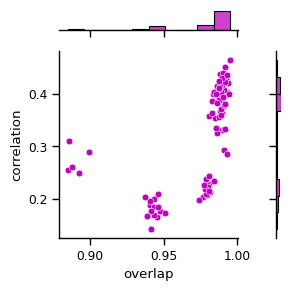

In [29]:
df = data.load_nci(data_path / "ovcar.csv")
dcorr = pd.DataFrame(
    [
        Row(*sample_assay_overlap(df, seed, fillna=True, progress=seed == 0))
        for seed in tqdm.tqdm(range(100))
    ]
)
sns.jointplot(
    dcorr,
    x="overlap",
    y="correlation",
    kind="scatter",
    color="m",
    marginal_ticks=False,
    marginal_kws=dict(bins=10),
    height=3,
)
plt.tight_layout()
dcorr.mean()

# Assay overlap in random splits

In [31]:
def sample_assay_overlap_random(df: pd.DataFrame, seed: int, fillna: bool = False):
    np.random.seed(seed)
    df["train"] = np.random.rand(len(df)) > 0.2
    df_train, df_test = df[df["train"]], df[~df["train"]]
    overlap = df_test[ASSAY].isin(df_train[ASSAY]).mean()
    predictor = df_train.groupby(ASSAY)[[ACT]].agg("mean")
    df_test = df_test.join(
        predictor.rename(columns={ACT: "assay_mean"}), on=ASSAY, how="left"
    )
    if fillna:
        df_test.fillna(value=df_train[ACT].mean(), inplace=True)
    corr = df_test.corr(numeric_only=True).loc["assay_mean", "activity_value"]

    return overlap, corr

## ChEMBL

sample overlap:   0%|          | 0/100 [00:00<?, ?it/s]

overlap        0.954324
correlation    0.778473
dtype: float64

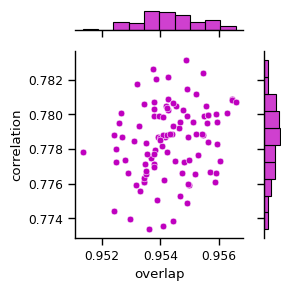

In [34]:
df = data.load_kinodata(data_path / "activities-chembl33_v0.5.csv")
dcorr = pd.DataFrame(
    [
        Row(*sample_assay_overlap_random(df, seed, fillna=True))
        for seed in tqdm.tqdm(range(100), desc="sample overlap")
    ]
)
sns.jointplot(
    dcorr,
    x="overlap",
    y="correlation",
    kind="scatter",
    color="m",
    marginal_ticks=False,
    marginal_kws=dict(bins=10),
    height=3,
)
plt.tight_layout()
plt.savefig("img/kinodata_scaffold_assay_overlap_random.pdf")
dcorr.mean()

  0%|          | 0/100 [00:00<?, ?it/s]

overlap        0.994539
correlation    0.813513
dtype: float64

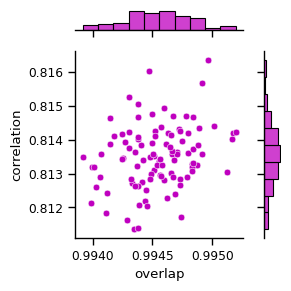

In [36]:
df = data.load_landrum(data_path / "omnivore.csv")
dcorr = pd.DataFrame(
    [
        Row(*sample_assay_overlap_random(df, seed, fillna=True))
        for seed in tqdm.tqdm(range(100))
    ]
)
sns.jointplot(
    dcorr,
    x="overlap",
    y="correlation",
    kind="scatter",
    color="m",
    marginal_ticks=False,
    marginal_kws=dict(bins=10),
    height=3,
)
plt.tight_layout()
plt.savefig("img/omnivore_scaffold_assay_overlap_random.pdf")
dcorr.mean()

  0%|          | 0/100 [00:00<?, ?it/s]

overlap        1.000000
correlation    0.805614
dtype: float64

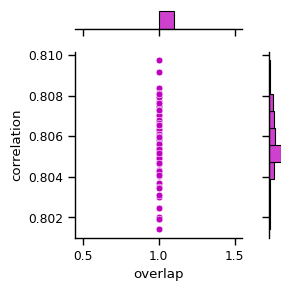

In [38]:
df = data.load_landrum(data_path / "landrum.csv")
dcorr = pd.DataFrame(
    [
        Row(*sample_assay_overlap_random(df, seed, fillna=True))
        for seed in tqdm.tqdm(range(100))
    ]
)
sns.jointplot(
    dcorr,
    x="overlap",
    y="correlation",
    kind="scatter",
    color="m",
    marginal_ticks=False,
    marginal_kws=dict(bins=10),
    height=3,
)
plt.tight_layout()
plt.savefig("img/landrum_scaffold_assay_overlap_random.pdf")
dcorr.mean()